=== エントロピー比較 ===
BA: 1.5874594347850532 0.6388406723127757
Random: 2.0253487583754506 0.8795977896920606


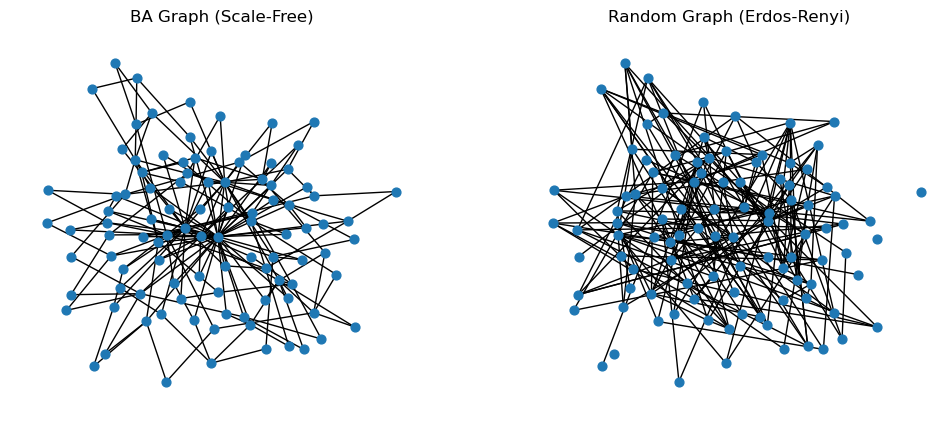

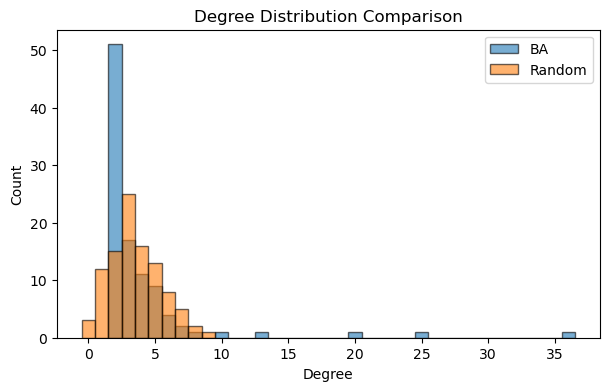

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter


# =========================================
# 0. グラフ生成
# =========================================
n = 100
m = 2

G_ba = nx.barabasi_albert_graph(n, m, seed=42)

# BAの平均次数 ≈ 2m → それに合わせる
p_er = (2 * m) / (n - 1)
G_rand = nx.erdos_renyi_graph(n=n, p=p_er, seed=42)


# =========================================
# 1. エントロピー関数
# =========================================
def degree_entropy(G):
    degrees = [d for _, d in G.degree()]
    count = Counter(degrees)
    N = sum(count.values())

    p = np.array([c / N for c in count.values()], dtype=float)

    H = -np.sum(p * np.log(p))
    H_norm = H / np.log(len(p)) if len(p) > 1 else 0.0

    return H, H_norm, degrees


# 計算
H_ba, Hn_ba, deg_ba = degree_entropy(G_ba)
H_rand, Hn_rand, deg_rand = degree_entropy(G_rand)


print("=== エントロピー比較 ===")
print("BA:", H_ba, Hn_ba)
print("Random:", H_rand, Hn_rand)


# =========================================
# 2. グラフ可視化（並べて比較）
# =========================================
plt.figure(figsize=(12, 5))

# 共通レイアウト（重要）
pos = nx.spring_layout(G_ba, seed=42)

# BA
plt.subplot(1, 2, 1)
nx.draw(G_ba, pos, node_size=40, with_labels=False)
plt.title("BA Graph (Scale-Free)")

# Random
plt.subplot(1, 2, 2)
nx.draw(G_rand, pos, node_size=40, with_labels=False)
plt.title("Random Graph (Erdos-Renyi)")

plt.show()


# =========================================
# 3. 次数分布比較（ヒストグラム）
# =========================================
plt.figure(figsize=(7, 4))

plt.hist(deg_ba,
         bins=range(min(deg_ba), max(deg_ba)+2),
         alpha=0.6,
         label="BA",
         edgecolor="black",
         align="left")

plt.hist(deg_rand,
         bins=range(min(deg_rand), max(deg_rand)+2),
         alpha=0.6,
         label="Random",
         edgecolor="black",
         align="left")

plt.xlabel("Degree")
plt.ylabel("Count")
plt.title("Degree Distribution Comparison")
plt.legend()
plt.show()